<h2>FasterRCNN</h2>
Celem projektu jest wytrenowanie modelu o architekturze Faster R-CNN do automatycznej detekcji i klasyfikacji obiektów oraz ocena jego skuteczności na wybranym datasecie.


1. <h5> Importowanie potrzebnych bibliotek oraz użycie GPU </h5>

In [44]:
import os
import random
import time
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from PIL import Image
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN 
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection import MeanAveragePrecision
from torchvision import tv_tensors
from torchvision import transforms as T
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou as tv_box_iou
from torchvision.models import ResNet34_Weights, ResNet18_Weights
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

print(f"PyTorch  : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

PyTorch  : 2.12.0+cu130
Torchvision: 0.27.0+cu130
Device   : cuda


<h5>2. Deklaracja części hiperparametrów oraz ścieżek do zapisu modeli oraz datasetu

In [ ]:
#----sciezki-----
DATASET_DIR = Path('../dataset')
IMG_DIR = DATASET_DIR / 'JPEGImages'
ANN_DIR = DATASET_DIR / 'Annotations_txt'
OUT_DIR = Path('.')
EPOCHS = 30
BATCH_SIZE = 4

with open(DATASET_DIR.resolve() / 'labels.txt', 'r', encoding='utf-8') as file:
    CLASSES = [line.strip().rstrip(',') for line in file if line.strip()]
NUM_CLASSES = len(CLASSES)   
CLS2IDX = {k: i for i, k in enumerate(CLASSES)}
KOLORY = plt.cm.tab10.colors


print("-------Ścieżki------")
print(f"Dataset:  {DATASET_DIR}")
print(f"Zdjęcia:  {IMG_DIR}")
print(f"Adnotacje:  {ANN_DIR}")
print(f"Output:  {OUT_DIR.resolve()}")
print("-------Hiperparametry------")
print(f"Liczba epok:  {EPOCHS}")
print(f"Rozmiar batcha:  {BATCH_SIZE}")
print(f"Klasy:  {CLASSES}")
print(f"Liczba klas:  {NUM_CLASSES}")
print(CLS2IDX)


-------Ścieżki------
Dataset:  ../dataset
Zdjęcia:  ../dataset/JPEGImages
Adnotacje:  ../dataset/Annotations_txt
Output:  /home/szarebski/Desktop/WFiIS-SSN-project/fastrcnn
-------Hiperparametry------
Liczba epok:  30
Rozmiar batcha:  4
Klasy:  ['sunglass', 'hat', 'jacket', 'shirt', 'pants', 'shorts', 'skirt', 'dress', 'bag', 'shoe']
Liczba klas:  10
{'sunglass': 0, 'hat': 1, 'jacket': 2, 'shirt': 3, 'pants': 4, 'shorts': 5, 'skirt': 6, 'dress': 7, 'bag': 8, 'shoe': 9}


<h5>3. Dataset </h5>
Wykorzystywany zbiór danych to Colorful Fashion Dataset For Object Detection, dostępny na kagglu. Przeznaczony jest do detekcji obiektów, jak sama nazwa wskazuje. Składa się z 10 klas oraz ok. 2680 obrazów. Obrazy bez ramek przechowywane są w folderze JPEGImages w formacie .jpg. Dane ramek znajdują się w folderach:<br>
- Annotations, w plikach typu .xml. Dostać się do danych można po węzłach "object", w których są węzły "name" - nazwa klasy, "bndbox" - węzeł zawierający węzły ze współrzędnymi "xmin", "ymin", "xmax", "ymax".<br>
- Alternatywnie, można wykorzystać dane z folderu Annotations_txt, które zawierają te same informacje podane w innej formie : id_klasy center_x, center_y, w, h, gdzie
pierwsza wartość to id_klasy podane w kolejności jak w pliku labels.txt, a reszta to wartości geometryczne po normalizacji do przedziału 0.0-1.0. center_x - środek bounding boxa w osi X, center_y - analogicznie w osi y, w - szerokośc ramki, h - wysokośc ramki.

<h5>3.1 Parsowanie datasetu </h5>
Została stworzona klasa ClothingDataset, która zajmuje się parsowaniem tego datasetu.
Najważniejszą metodą w tej klasie jest __getitem__(self,idx) - zajmuje się ona sparsowaniem obiektu o podanym id. Tworzy zmienne boxes, labels gdzie boxes to zbiór współrzędnych a labels to id_klasy tego bounding boxa przesunięte o 1, ze względu na to, że FasterCNN domyślnie uważa 0 za klasę __background__.<br>
Tworzony jest tensor BoundingBoxes wykorzystywany przez v2.Compose przy augmentacji. Zwracana jest krotka typu (tensor_obrazu, target), gdzie target to słownik {boxes, labels}.<br>
<h5>3.2 Podział danych </h5>
Dane zostały podzielone w stosunkach 70-15-15, kolejno dane treningowe, testowe oraz walidacyjne. Każde uruchomienie daje inaczej pomieszane dane, dlatego wyniki mogą się różnić (brak ustawionego seeda). Rozmiar batcha danych został ustalony na 4.
<h5>3.3 Augmentacja danych </h5>
Dane treningowe zostały poddane augmentacji: <br>
- RandomHorizontalFlip - 50% szans na obrócenie poziome obrazu i boundingboxów.<br>
- ColorJitter - losowe zmiany jasności, kontrastu, nasycenia i odcienia.<br>
- RandomGrayscale - 10% szans na konwersję do skali szarości (z 3 kanałami).<br>
Celem augmentacji jest uniknięcie przeuczenia poprzez zwiększenie róznorodności danych treningowych.

In [3]:
#parsowanie datasetu z txt
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    v2.RandomGrayscale(p=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

base_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])


class ClothingDataset(Dataset):
    def __init__(self, img_dir, ann_dir, ids, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.ids = ids
        self.transform = transform or base_transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img = Image.open(self.img_dir / f'{img_id}.jpg').convert('RGB')
        W, H = img.size

        boxes, labels = [], []
        with open(self.ann_dir / f'{img_id}.txt') as f:
            for line in f:
                cls, cx, cy, w, h = line.split()
                cx, cy, w, h = float(cx), float(cy), float(w), float(h)
                boxes.append([
                    (cx - w/2)*W, (cy - h/2)*H,
                    (cx + w/2)*W, (cy + h/2)*H,
                ])
                labels.append(int(cls) + 1)

        boxes_tv = tv_tensors.BoundingBoxes(
            torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            format="XYXY",
            canvas_size=(H, W),
        )
        img_out, boxes_out = self.transform(img, boxes_tv)

        target = {
            'boxes':  boxes_out.as_subclass(torch.Tensor),
            'labels': torch.tensor(labels, dtype=torch.int64),
        }
        return img_out.as_subclass(torch.Tensor), target


def collate_fn(batch):
    return tuple(zip(*batch))


# --- podział danych ---
all_ids = sorted(
    (p.stem for p in Path(ANN_DIR).glob('*.txt') if p.stem.isdigit()),
    key=int,
)
random.shuffle(all_ids)
n_val   = int(len(all_ids) * 0.15)
n_test  = int(len(all_ids) * 0.15)
test_ids  = all_ids[:n_test]
val_ids   = all_ids[n_test:n_test + n_val]
train_ids = all_ids[n_test + n_val:]

train_ds = ClothingDataset(IMG_DIR, ANN_DIR, ids=train_ids, transform=train_transform)
val_ds   = ClothingDataset(IMG_DIR, ANN_DIR, ids=val_ids)
test_ds  = ClothingDataset(IMG_DIR, ANN_DIR, ids=test_ids)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1878, Val: 402, Test: 402


<h5> 3.4 Podgląd danych </h5>

In [ ]:
imgs, targets = next(iter(train_loader))
print(imgs[0].shape)          
print(targets[0]['boxes'])    
print(targets[0]['labels'])

torch.Size([3, 600, 400])
tensor([[197.0000, 276.0000, 293.0000, 378.0000],
        [126.0000, 147.0000, 274.0000, 393.0000],
        [175.0000, 482.9997, 238.0000, 567.9999]])
tensor([ 9,  8, 10])


Wyświetlenie przykładowego obrazku z treningowego datasetu.

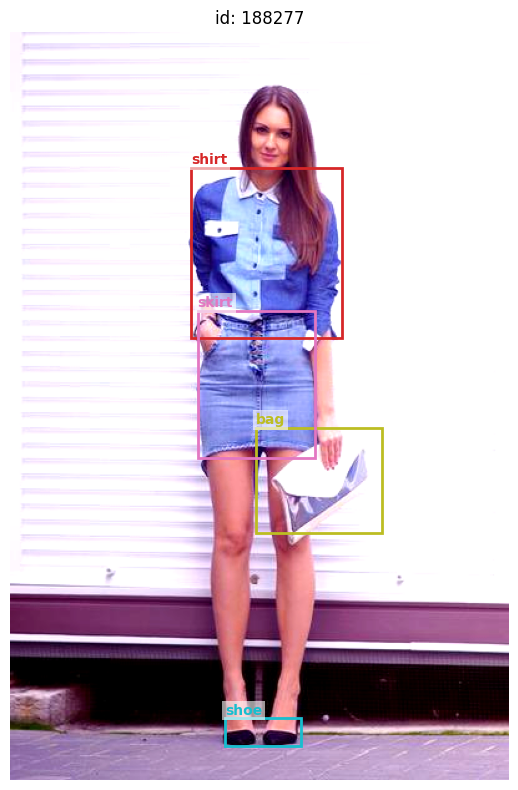

In [36]:
idx = random.randint(0, len(train_ds) - 1)
#Konwersja obrazu z CHW na HWC (Pytorch - > Matplotlib)
img_tensor, target = train_ds[idx]
img = img_tensor.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title(f'id: {train_ds.ids[idx]}', fontsize=12)
for box, lbl in zip(target['boxes'], target['labels']):
    x1, y1, x2, y2 = box.tolist()
    cls_idx = int(lbl) - 1 
    color = KOLORY[cls_idx % len(KOLORY)]
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 3, CLASSES[cls_idx], color=color, fontsize=10, weight='bold',
            bbox=dict(facecolor='white', alpha=0.6, pad=2, linewidth=0))
            
plt.tight_layout()
plt.show()

<h3> 4. Trening modelu

<h5> 4.1 Ustawienia modelu baseline </h5>
Pierwszy model został użyty do sprawdzenia, czy kod w ogóle zadziała oraz jakie predykcje da, stąd ustalone hiperparametry. <br>
Jako backbone, został wybrany model Faster R-CNN z backbone ResNet50. Wagi modelu są domyślne.<br>
Następnie podmieniamy końcówkę sieci aby rozpoznawała nasze 11 klas zamiast poprzedniej ilości. <br> 
Learning rate ustalony na 1e-4, wraz ze schedulerem typu step, który mnoży lr o parametr gamma ustawiony na 0.1 co 10 epok. <br>
Optymalizator został ustawiony na AdamW - Adam z lepszym weight decay.

In [ ]:
model = fasterrcnn_resnet50_fpn(weights='DEFAULT', min_size=400, max_size=600)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES+1)
model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
parametry = sum(p.numel() for p in model.parameters())
print(f'Liczba parametrów modelu: {parametry:,}')

Liczba parametrów modelu: 41,345,286


<h5> 4.2 Trening modelu </h5>
1. Inicjalizacja parametrów i historii treningu - ustawienie PATIENCE do early stoppingu na 5 epok, stworzenie słownika history który gromadzi wartości błędów całkowitych treningu, walidacji, błąd obiektywności (mierzy czy w danym miejscu na zdjęciu jest w ogóle jakiś obiekt czy tylko tło), błąd regresjii ramek rpn (błąd położenia ramek wygenerowanych w porówaniu do rzeczywistych ramek na zdjęciu). <br>
2. Pętla treningowa: <br>
2.1 Trening modelu w pętli.<br>
2.2 Dla każdego batcha w train_loader:<br>
- Przeniesienie go na GPU <br>
- forward pass - obliczanie błędów <br>
- Sumwoanie błędów wszystkich batchy <br>
- Backward pass - obliczanie nowych gradientów i aktualizacja wag modelu <br>
- zapisanie statystyk z konkretnego batcha do zmiennych pomocnicznych <br>
2.3 Uśrednianie błędów i dopisanie do głównego słownika. <br>
3. Walidacja na danych walidacyjnych, brak obliczania oraz zmiany gradientów. <br>
4. Aktualizacja kroku schedulera. <br>
5. Early stopping jeżeli model nie poprawił się przez 5 epok oraz zapis modelu do głównego folderu. <br>
6. Wyprintowanie postępu po upłynięciu epoki. <br>


In [ ]:
#trening modelu
#inicjalizacja early stopping i słownika z błędami history
PATIENCE = 5
history = {'train_loss': [], 'val_loss': [], 'loss_classifier': [], 'loss_box_reg': [],
           'loss_objectness': [], 'loss_rpn_box_reg': [], 'lr': []}
best_val_loss = float('inf')
no_improve    = 0

#pętla treningowa
for epoch in range(EPOCHS):
    model.train()
    epoch_losses = {k: 0.0 for k in history if k not in ('val_loss', 'lr')}
    for images, targets in train_loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses['train_loss']       += loss.item()
        epoch_losses['loss_classifier']  += loss_dict['loss_classifier'].item()
        epoch_losses['loss_box_reg']     += loss_dict['loss_box_reg'].item()
        epoch_losses['loss_objectness']  += loss_dict['loss_objectness'].item()
        epoch_losses['loss_rpn_box_reg'] += loss_dict['loss_rpn_box_reg'].item()
    for k in epoch_losses:
        history[k].append(epoch_losses[k] / len(train_loader))
    history['lr'].append(optimizer.param_groups[0]['lr'])

    #walidacja
    model.train() 
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            val_loss += sum(loss_dict.values()).item()
    val_loss /= len(val_loader)
    history['val_loss'].append(val_loss)
    #krok schedulera
    scheduler.step()

    #early stopping i zapisanie modelu
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), OUT_DIR / 'best_model_1.pth')
        tag = ' saved'
    else:
        no_improve += 1
        tag = f'  (patience {no_improve}/{PATIENCE})'
    #printowanie danych po epoce
    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"train: {history['train_loss'][-1]:.4f} | "
          f"val: {val_loss:.4f} | "
          f"cls: {history['loss_classifier'][-1]:.4f} | "
          f"box: {history['loss_box_reg'][-1]:.4f} | "
          f"obj: {history['loss_objectness'][-1]:.4f} | "
          f"rpn: {history['loss_rpn_box_reg'][-1]:.4f} | "
          f"lr: {history['lr'][-1]:.2e}{tag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping po epoce {epoch+1} - brak poprawy val_loss przez {PATIENCE} epok.")
        break

Epoch  1/30 | train: 0.6222 | val: 0.5324 | cls: 0.2487 | box: 0.3293 | obj: 0.0306 | rpn: 0.0137 | lr: 1.00e-04 saved
Epoch  2/30 | train: 0.4832 | val: 0.4819 | cls: 0.1801 | box: 0.2718 | obj: 0.0197 | rpn: 0.0117 | lr: 1.00e-04 saved
Epoch  3/30 | train: 0.4473 | val: 0.4411 | cls: 0.1632 | box: 0.2566 | obj: 0.0166 | rpn: 0.0108 | lr: 1.00e-04 saved
Epoch  4/30 | train: 0.4192 | val: 0.4531 | cls: 0.1494 | box: 0.2466 | obj: 0.0132 | rpn: 0.0099 | lr: 1.00e-04  (patience 1/5)
Epoch  5/30 | train: 0.3896 | val: 0.4504 | cls: 0.1363 | box: 0.2335 | obj: 0.0105 | rpn: 0.0094 | lr: 1.00e-04  (patience 2/5)
Epoch  6/30 | train: 0.3693 | val: 0.4547 | cls: 0.1259 | box: 0.2252 | obj: 0.0092 | rpn: 0.0089 | lr: 1.00e-04  (patience 3/5)
Epoch  7/30 | train: 0.3455 | val: 0.4445 | cls: 0.1155 | box: 0.2140 | obj: 0.0077 | rpn: 0.0083 | lr: 1.00e-04  (patience 4/5)
Epoch  8/30 | train: 0.3221 | val: 0.4597 | cls: 0.1061 | box: 0.2008 | obj: 0.0071 | rpn: 0.0081 | lr: 1.00e-04  (patience 5/5

<h5> 5. Wczytanie najlepszego modelu - wyniki , wizualizacje, metryki na danych testowych.

In [40]:
# --- ewaluacja: mAP@50, mAP@50-95, recall, czas inferencji ---


model.load_state_dict(torch.load(OUT_DIR / 'best_model_1.pth', map_location=DEVICE))
model.eval()

metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

total_time = 0.0
n_images   = 0

with torch.no_grad():
    for images, targets in test_loader:
        images_gpu = [img.to(DEVICE) for img in images]

        t0 = time.perf_counter()
        preds = model(images_gpu)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        total_time += time.perf_counter() - t0
        n_images   += len(images)

        preds_fmt = [
            {'boxes': p['boxes'].cpu(), 'scores': p['scores'].cpu(), 'labels': p['labels'].cpu()}
            for p in preds
        ]
        targets_fmt = [
            {'boxes': t['boxes'].cpu(), 'labels': t['labels'].cpu()}
            for t in targets
        ]
        metric.update(preds_fmt, targets_fmt)

results = metric.compute()
avg_ms  = total_time / n_images * 1000

print(f"{'mAP@50:':<18} {results['map_50']:.4f}")
print(f"{'mAP@50-95:':<18} {results['map']:.4f}")
print(f"{'Recall@100:':<18} {results['mar_100']:.4f}")
print(f"{'Czas inferencji:':<18} {avg_ms:.1f} ms/obraz  ({1000/avg_ms:.1f} FPS)")
print()
print(f"{'Klasa':<12} {'AP@50':>8} {'Recall':>8}")
print("-" * 30)
for i, cls in enumerate(CLASSES):
    ap  = results['map_per_class'][i].item()
    rec = results['mar_100_per_class'][i].item()
    print(f"{cls:<12} {ap:>8.4f} {rec:>8.4f}")


mAP@50:            0.7957
mAP@50-95:         0.4456
Recall@100:        0.5914
Czas inferencji:   27.9 ms/obraz  (35.8 FPS)

Klasa           AP@50   Recall
------------------------------
sunglass       0.1055   0.3720
hat            0.3520   0.4883
jacket         0.5739   0.6801
shirt          0.4559   0.6004
pants          0.6495   0.7386
shorts         0.4418   0.5928
skirt          0.5636   0.6889
dress          0.5558   0.6950
bag            0.3687   0.5303
shoe           0.3889   0.5278


<h5>5.1 Wizualizacja predykcji </h5> Przerywane ramki to ground truth, ciągłe ramki to predykcje modelu. Parametr SCORE_TRHESH określa próg pewności poniżej którego nie pokazuje predykcji.<br>
Funkcja show_predictions przyjmuje model, dataset, liczbe obrazow do wyswietlenia, liczbe kolumn siatki oraz próg pewności predykcji. <br>
Następnie wybiera losowe obrazy z datasetu treningowego, tworzy siatkę wykresów.
W pętli wczytuje obrazy i ground truth z datasetu, konwertuje na format matplotlib, model tworzy predykcje i zachowuje te które mają pewnośc > SCORE_THRESH. <br>
Na koniec obrazy są wyświetlane oraz rysowane są etykiety, legendy oraz bounding boxy:<br>
- Ground truth - linią przerywaną <br>
- Predykcja - linią ciągłą <br>

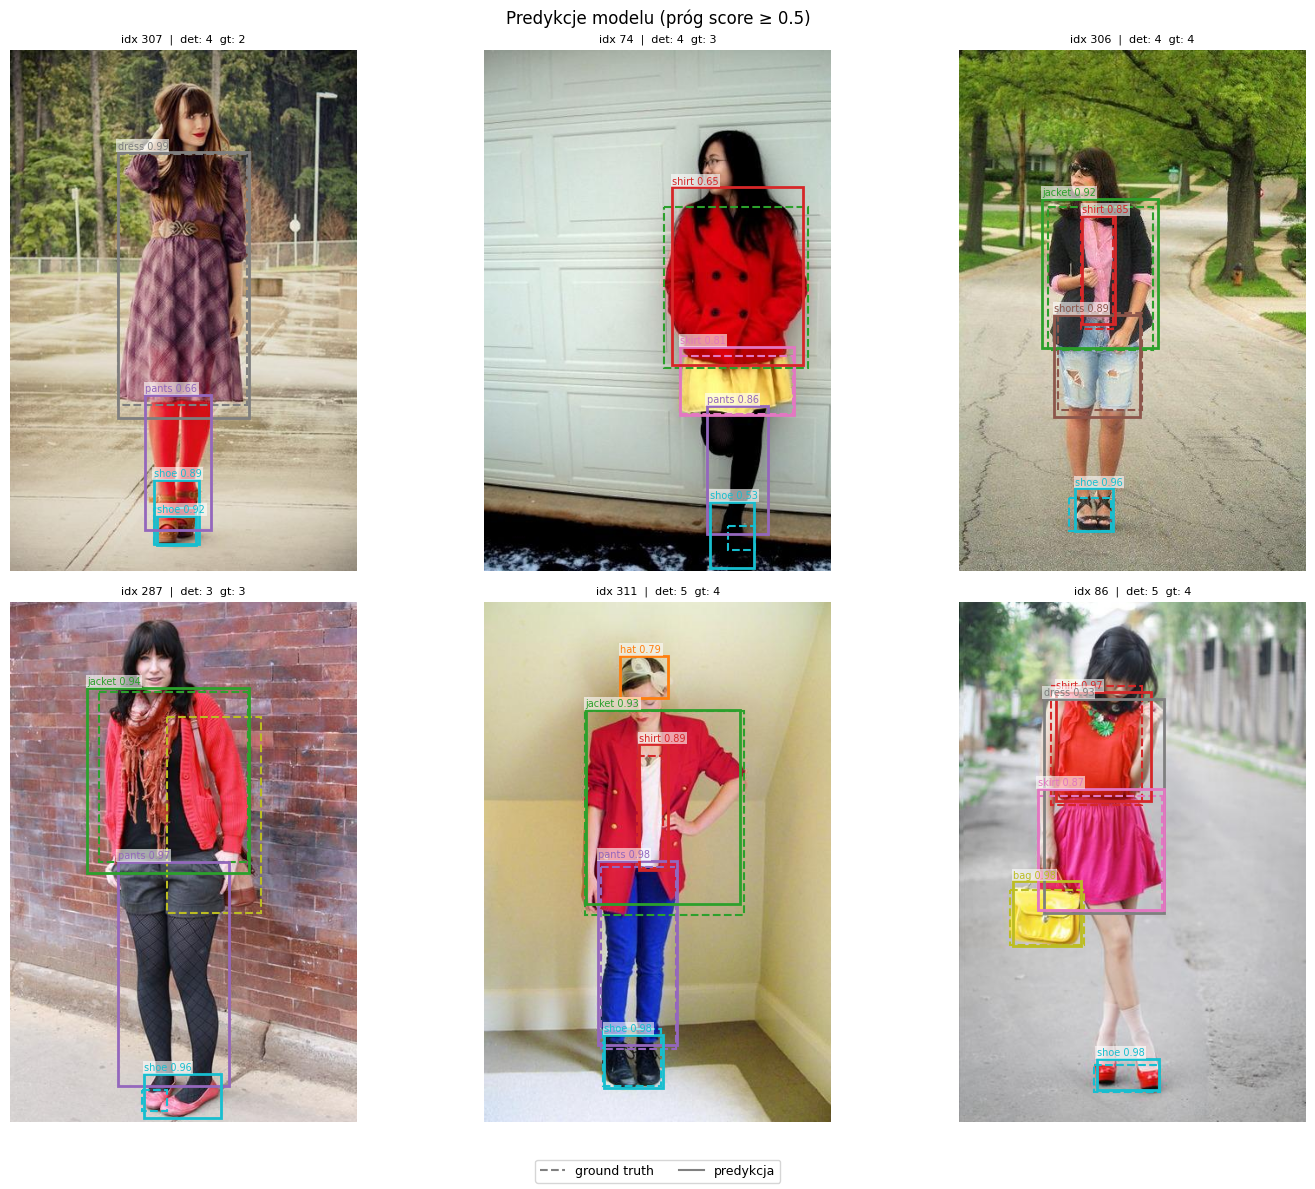

In [ ]:

#wizualizacja predykcji na obrazach testowych
SCORE_THRESH = 0.5
def show_predictions(model, dataset, n=6, cols=3, score_thresh=SCORE_THRESH):
    model.eval()
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 6))
    axes = axes.flatten()
    indices = random.sample(range(len(dataset)), n)
    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_tensor, target = dataset[idx]
            img = img_tensor.permute(1, 2, 0).numpy()
            pred = model([img_tensor.to(DEVICE)])[0]
            keep = pred['scores'] >= score_thresh
            pred_boxes  = pred['boxes'][keep].cpu()
            pred_labels = pred['labels'][keep].cpu()
            pred_scores = pred['scores'][keep].cpu()
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f'idx {idx}  |  det: {len(pred_boxes)}  gt: {len(target["boxes"])}', fontsize=8)
            # ground truth - linia przerywana
            for box, lbl in zip(target['boxes'], target['labels']):
                x1, y1, x2, y2 = box.tolist()
                cls_idx = int(lbl) - 1
                color = KOLORY[cls_idx % len(KOLORY)]
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=1.5, edgecolor=color, facecolor='none', linestyle='--'
                )
                ax.add_patch(rect)
            # predykcje - linia ciągła + score pewnności
            for box, lbl, score in zip(pred_boxes, pred_labels, pred_scores):
                x1, y1, x2, y2 = box.tolist()
                cls_idx = int(lbl) - 1
                color = KOLORY[cls_idx % len(KOLORY)]
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f'{CLASSES[cls_idx]} {score:.2f}',
                        color=color, fontsize=7,
                        bbox=dict(facecolor='white', alpha=0.6, pad=1, linewidth=0))
    for ax in axes[n:]:
        ax.axis('off')
    legend_elements = [
        Line2D([0], [0], linestyle='--', color='gray', label='ground truth'),
        Line2D([0], [0], linestyle='-',  color='gray', label='predykcja'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9)
    plt.suptitle(f'Predykcje modelu (próg score ≥ {score_thresh})', fontsize=12)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()



show_predictions(model, test_ds, n=6, cols=3)


<h5> 5.2 Rozkład IoU dla predykcji w zależności od thresholdu pewności oraz progu nakładania się ramek </h5>

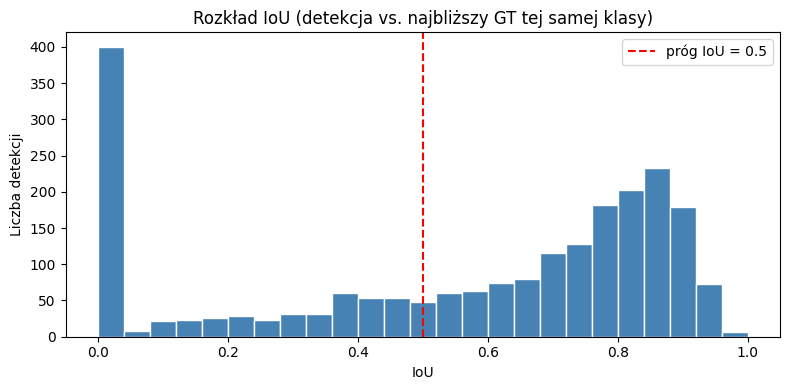

TP (IoU ≥ 0.5): 1424  (64.6%)
FP (IoU < 0.5):  782  (35.4%)
Średnio IoU: 0.5552  |  Mediana IoU: 0.6839


In [ ]:
#Rozkład IoU dla predykcji


SCORE_THRESH_EVAL = 0.5
IOU_THRESH_EVAL   = 0.5
all_ious = []
model.eval()
with torch.no_grad():
    #pętla po batchach obrazów
    for images, targets in test_loader:
        images_gpu = [img.to(DEVICE) for img in images]
        preds = model(images_gpu)
        #pętla po pojedyńczych obrazach w batchu
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes']
            gt_labels = target['labels']
            #filtrowanie słabych predykcji
            mask       = pred['scores'] >= SCORE_THRESH_EVAL
            pred_boxes = pred['boxes'][mask].cpu()
            pred_lbls  = pred['labels'][mask].cpu()
            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue
            #pętla po każdej predykcji
            for pbox, plbl in zip(pred_boxes, pred_lbls):
                gt_mask = (gt_labels == plbl)
                if gt_mask.sum() == 0:
                    all_ious.append(0.0)
                    continue
                #obliczanie iou i dodanie do listy
                ious = tv_box_iou(pbox.unsqueeze(0), gt_boxes[gt_mask])[0]
                all_ious.append(ious.max().item())
#wyrysowanie histogramu iou, linii progu iou
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_ious, bins=25, range=(0, 1), color='steelblue', edgecolor='white')
ax.axvline(IOU_THRESH_EVAL, color='red', linestyle='--',
           label=f'próg IoU = {IOU_THRESH_EVAL}')
ax.set_xlabel('IoU')
ax.set_ylabel('Liczba detekcji')
ax.set_title('Rozkład IoU (detekcja vs. najbliższy GT tej samej klasy)')
ax.legend()
plt.tight_layout()
plt.show()

tp_cnt = sum(1 for v in all_ious if v >= IOU_THRESH_EVAL)
fp_cnt = len(all_ious) - tp_cnt
print(f"TP (IoU \u2265 {IOU_THRESH_EVAL}): {tp_cnt}  ({100*tp_cnt/len(all_ious):.1f}%)")
print(f"FP (IoU < {IOU_THRESH_EVAL}):  {fp_cnt}  ({100*fp_cnt/len(all_ious):.1f}%)")
print(f"\u015arednio IoU: {np.mean(all_ious):.4f}  |  Mediana IoU: {np.median(all_ious):.4f}")


Jak widać na wykresie, dla pewności przewidywań > 50%, duża częśc detekcji ma IoU w okolicach 0.0. Oznacza to, że duża część predykcji jest fałszywa oraz nie ma tam w ogóle obiektów. Poza tymi przypadkami, widać wzrost dla IoU z zakresu 0.4-0.9. Oznacza to, że te detekcje, które są wykryte poprawnie mają dobry próg pokrycia (>0.5). True predictions przyjmujemy jako takie, gdzie miara IoU jest większa od wybranego progu (w naszym przypadku 50%). 

<h5> 5.3 Analiza błędnie przypisanych klas </h5>

Precision: 0.5984
Recall:    0.8505
F1:        0.7025
(score ≥ 0.5, IoU ≥ 0.5)



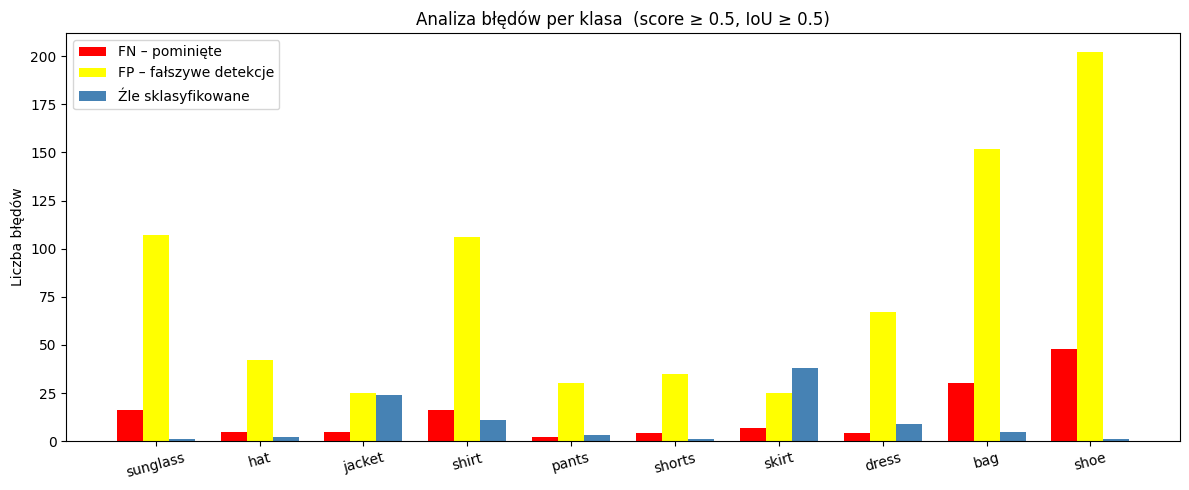

FN  – pominięte obiekty:   137
FP  – fałszywe detekcje:  791
Źle sklasyfikowane:        95


In [ ]:
#analiza błędów: FN, FP, źle sklasyfikowane
SCORE_THRESH_EVAL = 0.5
IOU_THRESH_EVAL   = 0.5
fn_per_cls    = defaultdict(int) #pominięte obiekty
fp_per_cls    = defaultdict(int) #fałszywe detekcje
misclass_per_cls = defaultdict(int) #dobrze zlokalizowane ale źle sklasyfikowane
tp_total  = 0
det_total = 0
gt_total  = 0
model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images_gpu = [img.to(DEVICE) for img in images]
        preds = model(images_gpu)
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes']
            gt_labels = target['labels']
            gt_total += len(gt_labels)
            mask       = pred['scores'] >= SCORE_THRESH_EVAL
            pred_boxes = pred['boxes'][mask].cpu()
            pred_lbls  = pred['labels'][mask].cpu()
            det_total += len(pred_boxes)
            matched_gt = set()
            for pbox, plbl in zip(pred_boxes, pred_lbls):
                if len(gt_boxes) == 0:
                    fp_per_cls[CLASSES[int(plbl)-1]] += 1
                    continue
                ious   = tv_box_iou(pbox.unsqueeze(0), gt_boxes)[0]
                best_v, best_j = ious.max(0)
                best_j = best_j.item()
                #decyzja dla każdej predykcji
                if best_v.item() >= IOU_THRESH_EVAL and best_j not in matched_gt:
                    matched_gt.add(best_j)
                    gt_lbl = gt_labels[best_j].item()
                    if gt_lbl == int(plbl):
                        tp_total += 1
                    else:
                        misclass_per_cls[CLASSES[gt_lbl-1]] += 1
                else:
                    fp_per_cls[CLASSES[int(plbl)-1]] += 1
            for j, gt_lbl in enumerate(gt_labels.tolist()):
                if j not in matched_gt:
                    fn_per_cls[CLASSES[gt_lbl-1]] += 1

# metryki globalne
precision = tp_total / det_total if det_total else 0.0
recall    = tp_total / gt_total  if gt_total  else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"(score \u2265 {SCORE_THRESH_EVAL}, IoU \u2265 {IOU_THRESH_EVAL})")
print()

# wykres
fn_vals = [fn_per_cls[c]    for c in CLASSES]
fp_vals = [fp_per_cls[c]    for c in CLASSES]
mc_vals = [misclass_per_cls[c] for c in CLASSES]
x = np.arange(len(CLASSES))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, fn_vals, w, label='FN pominięte',         color='red')
ax.bar(x,     fp_vals, w, label='FP fałszywe detekcje', color='yellow')
ax.bar(x + w, mc_vals, w, label='Źle sklasyfikowane',           color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=15)
ax.set_ylabel('Liczba błędów')
ax.set_title(f'Analiza błędów per klasa  (score \u2265 {SCORE_THRESH_EVAL}, IoU \u2265 {IOU_THRESH_EVAL})')
ax.legend()
plt.tight_layout()
plt.show()
total_fn = sum(fn_vals)
total_fp = sum(fp_vals)
total_mc = sum(mc_vals)
print(f"FN  \u2013 pominięte obiekty:   {total_fn}")
print(f"FP  \u2013 fałszywe detekcje:  {total_fp}")
print(f"Źle sklasyfikowane:        {total_mc}")


Z powyższego wykresu wynika, że model ma największe problemy z fałszywą detekcją koszuli, torby, butów oraz okularów przeciwsłonecznych. W przypadku okularów przeciwsłonecznych, butów oraz torby może to być przez to, że są to mniejsze obiekty, co za tym idzie mniejsze bounding boxy niż np. sukienka.

<h5> 6. Porównanie hiperparametrów oraz trening innych modeli </h5>
Podpunkt ma na celu przetestowanie jak zmieni się wartość funkcji straty modeli na danych walidacyjnych w zależności od hiperparametrów modeli, takich jak: optimizer, scheduler, learning rate, wielkość modelu oraz zamrożenie kilku warstw modelu. <br>
Zostało przeprowadzone tylko kilka eksperymentów ze względu na wysokie koszty obliczeniowe trenowania każdego modelu.

Trening modeli do eksperymentów jest przeprowadzony podobnie do wcześniej opisanego treningu, główną różnicą jest wybranie różnych modeli jako backbone, określenie schedulera, optymalizatora, batch_size, augmentacji oraz learning rate w parametrach funkcji oraz wypisanie metryk obliczonych na zbiorze testowym.

<h5> 6.1 Dostosowanie hiperparametrów modelu </h5>

In [ ]:
#funkcja do trenowania modelu w zależności od podanych hiperparametrów
def run_experiment(name, aug=False, lr=1e-4, optim_name='adam', sched_name='step',
                   batch_size=BATCH_SIZE, epochs=EPOCHS, patience=PATIENCE,
                   model_factory=None):
    print(f"\n{'='*64}")
    print(f"  {name}  |  optim={optim_name}  lr={lr:.0e}  sched={sched_name}  aug={aug}  bs={batch_size}")
    print(f"{'='*64}")
    tr_transform = train_transform if aug else base_transform
    tr_ds     = ClothingDataset(IMG_DIR, ANN_DIR, ids=train_ids, transform=tr_transform)
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    if model_factory is None:
        mdl = fasterrcnn_resnet50_fpn(weights='DEFAULT', min_size=400, max_size=600)
        mdl.roi_heads.box_predictor = FastRCNNPredictor(
            mdl.roi_heads.box_predictor.cls_score.in_features, NUM_CLASSES + 1
        )
    else:
        mdl = model_factory()
    mdl.to(DEVICE)

    #optimizer
    #adam
    if optim_name == 'adam':
        opt = torch.optim.Adam(mdl.parameters(), lr=lr)
    #adamw
    elif optim_name =='adamw':
        opt=torch.optim.AdamW(mdl.parameters(), lr=lr)
    else:
        # sgd
        opt = torch.optim.SGD(mdl.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    #scheduler
    #step
    if sched_name == 'step':
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.1)
    else:  #cosine
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    #trening
    ckpt      = OUT_DIR / f'exp_{name}.pth'
    best_val  = float('inf')
    no_improve = 0
    t_start   = time.perf_counter()

    for epoch in range(epochs):
        mdl.train()
        train_loss = 0.0
        for images, targets in tr_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = mdl(images, targets)
            loss = sum(loss_dict.values())
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_loss += loss.item()
        train_loss /= len(tr_loader)

        #walidacja
        mdl.train()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images  = [img.to(DEVICE) for img in images]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
                val_loss += sum(mdl(images, targets).values()).item()
        val_loss /= len(val_loader)

        sched.step()

        if val_loss < best_val:
            best_val   = val_loss
            no_improve = 0
            torch.save(mdl.state_dict(), ckpt)
            tag = ' saved'
        else:
            no_improve += 1
            tag = f'  (patience {no_improve}/{patience})'

        print(f"  Ep {epoch+1:>2}/{epochs} | train: {train_loss:.4f} | val: {val_loss:.4f}{tag}")

        if no_improve >= patience:
            print(f"  Early stopping po epoce {epoch+1}")
            break

    t_train = time.perf_counter() - t_start

    #ewaluacja na zbiorze testowym
    mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    mdl.eval()
    metric = MeanAveragePrecision(iou_type='bbox')
    t_inf = 0.0
    n_img = 0
    with torch.no_grad():
        for images, targets in test_loader:
            imgs_gpu = [img.to(DEVICE) for img in images]
            t0 = time.perf_counter()
            preds = mdl(imgs_gpu)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            t_inf += time.perf_counter() - t0
            n_img += len(images)
            metric.update(
                [{'boxes': p['boxes'].cpu(), 'scores': p['scores'].cpu(), 'labels': p['labels'].cpu()} for p in preds],
                [{'boxes': t['boxes'].cpu(), 'labels': t['labels'].cpu()} for t in targets],
            )
    #obliczanie metryk
    res = metric.compute()

    row = {
        'nazwa':       name,
        'optim':       optim_name,
        'lr':          lr,
        'scheduler':   sched_name,
        'aug':         aug,
        'mAP@50':      round(res['map_50'].item(),  4),
        'mAP@50-95':   round(res['map'].item(),     4),
        'Recall@100':  round(res['mar_100'].item(), 4),
        'best_val':    round(best_val,              4),
        'czas [min]':  round(t_train / 60,          1),
        'inf [ms]':    round(t_inf / n_img * 1000,  1),
    }
    print(f"\n mAP@50={row['mAP@50']:.4f}  mAP@50-95={row['mAP@50-95']:.4f}  Recall={row['Recall@100']:.4f}")
    return row

Wykonanie wszystkich wypisanych eksperymentów:
- baseline-adam : augmentacja, learning rate 1e-4, opytmalizator adam, scheduler typu step 10 epok gamma 0.1, <br>
- adamw : augmentacja, learning rate 1e-4, opytmalizator adamw, scheduler typu step 10 epok gamma 0.1, <br>
- lr-low : augmentacja, learning rate 1e-5, opytmalizator adamw, scheduler typu step 10 epok gamma 0.1, <br>
- sgd : augmentacja, learning rate 1e-3, opytmalizator sgd, scheduler typu step 10 epok gamma 0.1, <br>
- cosine-sgd : augmentacja, learning rate 1e-4, opytmalizator sgd, scheduler typu cosine<br>
- cosine-adam : augmentacja, learning rate 1e-4, opytmalizator adam, scheduler typu cosine <br>
- no-aug-adam-cosine: bez augmentacji, learning rate 1e-4, opytmalizator adam, scheduler typu cosine <br>


In [ ]:
experiments = [
    dict(name='baseline-adam',   aug=True, lr=1e-4, optim_name='adam', sched_name='step'),
    dict(name='adamw',        aug=True,  lr=1e-4, optim_name='adamw', sched_name='step'),
    dict(name='lr-low',     aug=True, lr=1e-5, optim_name='adamw', sched_name='step'),
    dict(name='sgd',        aug=True, lr=1e-3, optim_name='sgd',  sched_name='step'),
    dict(name='cosine-sgd',     aug=True, lr=1e-4, optim_name='sgd', sched_name='cosine'),
    dict(name='cosine-adam', aug=True,  lr=1e-4, optim_name='adam', sched_name='cosine'),
    dict(name='no-aug-adam-cosine', aug=False,  lr=1e-4, optim_name='adam', sched_name='cosine'),
]

wyniki = []
for cfg in experiments:
    wyniki.append(run_experiment(**cfg))

df = (pd.DataFrame(wyniki)
        .sort_values('mAP@50', ascending=False)
        .reset_index(drop=True))

(df.style
   .highlight_max(subset=['mAP@50', 'mAP@50-95', 'Recall@100'], color='#b6f0b6')
   .highlight_min(subset=['best_val', 'inf [ms]'],               color='#b6d8f0')
   .format({'lr': '{:.0e}', 'mAP@50': '{:.4f}', 'mAP@50-95': '{:.4f}',
            'Recall@100': '{:.4f}', 'best_val': '{:.4f}'})
)

<h5> 6.2 Eksperymenty na mniejszych architekturach </h5>
ResNet34 i ResNet18 jako backbone Faster RCNN. Porównanie z ResNet50 pod kątem prędkości inferencji i dokładności. Do eksperymentów na mniejszych architekturach wybrano optimizer SGD, scheduler step oraz learning rate 1e-3 ze względu na najlepsze wyniki w poprzednich eksperymentach.

In [ ]:


def make_resnet34():
    backbone = resnet_fpn_backbone(
        'resnet34',
        weights=ResNet34_Weights.IMAGENET1K_V1,
        trainable_layers=5,
    )
    mdl = FasterRCNN(backbone, num_classes=NUM_CLASSES + 1, min_size=400, max_size=600)
    print(f"  [resnet34] parametrów: {sum(p.numel() for p in mdl.parameters()):,}")
    return mdl


def make_resnet18():
    backbone = resnet_fpn_backbone(
        'resnet18',
        weights=ResNet18_Weights.IMAGENET1K_V1,
        trainable_layers=5,
    )
    mdl = FasterRCNN(backbone, num_classes=NUM_CLASSES + 1, min_size=400, max_size=600)
    print(f"  [resnet18] parametrów: {sum(p.numel() for p in mdl.parameters()):,}")
    return mdl


exp_r34 = run_experiment(
    'resnet34', optim_name='sgd', lr=1e-3, sched_name='step',
    model_factory=make_resnet34,
)
exp_r18 = run_experiment(
    'resnet18', optim_name='sgd', lr=1e-3, sched_name='step',
    model_factory=make_resnet18,
)

df_arch = pd.DataFrame([exp_r34, exp_r18]).reset_index(drop=True)

(df_arch.style
        .highlight_max(subset=['mAP@50', 'mAP@50-95', 'Recall@100'], color='#b6f0b6')
        .highlight_min(subset=['best_val', 'inf [ms]'],               color='#b6d8f0')
        .format({'lr': '{:.0e}', 'mAP@50': '{:.4f}', 'mAP@50-95': '{:.4f}',
                 'Recall@100': '{:.4f}', 'best_val': '{:.4f}'})
)

<h5> 6.3 Wyniki eksperymentów </h5>
Wyniki powyższych eksperymentów zostały zapisane do plików zawierających: <br>
- wyniki treningu modeli - do plików tekstowych o nazwach train_output_6_X.txt, gdzie X to podpunkt w notebooku z którego pochodzą wyniki. <br>
- wartości metryk modelu na danych testowych - do plików .png o nazwach test_results_6_X.png, gdzie X to podpunkt w notebooku z którego pochodzą wyniki. <br>

Z powyższych wyników można wyciągnąć poniższe wnioski:<br>
- trening modeli był przerywany dosyć wcześnie, bo w kilku przypadkach w epokach 8-11. W przerywaniu modeli była brana pod uwagę wartość funkcji straty przy walidacji, co może sugerować, że model szybko się przeuczał.<br>
- najdłużej trwał trening modelu z optymalizatorem SGD oraz schedulerem typu cosine. Wykorzystał wszystkie 30 epok, a mimo to nie osiągnął najlepszych rezultatów, jednocześnie generując duży koszt obliczeniowy. Poprawa w ostatnich epokach tego modelu była minimalna. <br>
- najszybciej nauczył się model bez augmentacji z optymalizatorem adam oraz schedulerem cosine. Jednak ze względu na to, że najlepszy wynik był znaleziony w trzeciej epoce, a trening przerwany w ósmej, jest szansa na overfitting. <br>
- mniejsze modele osiągały gorsze rezultaty, ale zajmowały także o połowę mniej czasu treningowego. <br>
- zdecydowanie najlepiej poradził sobie model wykorzystujący optymalizator SGD z learning rate 1e-3. Mimo drugiego najwyższego czasu treningu nie odbiegał od reszty znacząco pod tym względem, a generował największą wartość metryki mAP@50-95 oraz nieznacznie niższą mAP@50 od najlepszej.
<br>
- w przypadku, gdy najbardziej interesuje nas dokładność warto postawić na model 'sgd'<br>

7. Metryki dla najlepszego modelu <br>

8. Uruchomienie

Wymagany jest python 3.11.15 oraz zależności z pliku requirements.txt instalowane poprzez komendę:<br>
pip install -r fastrcnn/requirements.txt<br>
uruchamianą z głównego folderu projektu.
Następnie można odtworzyć cały proces poprzez uruchamianie komórek w notebooku po kolei.